# Synthetic methods adjudication

## tl;dr

This notebook consolidates the synthetic experiments by **estimand**, **training objective**, and **claim ceiling**. It also analyzes two targeted follow-ups run on July 12, 2026: a 250-case objective-parity panel and a ten-seed finite-contrast adapter study. The central result is that no single method is best for all quantities: likelihood methods dominate conditional-law and tail prediction, simple parametric likelihood is strongest for mean/dispersion fields, finite contrasts help only on supported location/interaction changes, and neither score-based nor likelihood methods identify synaptic gating without a model/experiment that represents that operation.

## Context & Methods

The comparison is partitioned into: predictive law (P1), finite-time operator recovery (D1), reduced-form history channels (M1), physical modulator fields (M2), latent recovery (L1), controlled intervention response (C1), graph localization, and changepoint detection. Metrics are not pooled across these claim levels.

### Key assumptions

- Lower NLL, RMSE, NRMSE, and nISE are better; nISE=1 is the zero-field baseline when the truth field is nonzero.
- DSM risks are comparable only for the same corruption kernel, scale, scored variables, and conditioning domain.
- SBTG joint-state DSM and conditional outcome DSM target different scores.
- Synthetic M2/C1 results apply to the implemented simulator, not automatically to biological neuromodulation.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
OUT = ROOT / "analysis" / "synthetic_methods_adjudication"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
objective = pd.read_csv(ROOT / "neuromod_benchmark/outputs/objective_adjudication_20260712/metrics_summary.csv", keep_default_na=False)
finite_files = [ROOT / f"history_tangent_benchmark/results/revised_note_v1_finite_contrast_20260712_seed{s}/finite_contrast_metrics.csv" for s in range(5004, 5014)]
finite = pd.concat([pd.read_csv(p).assign(adapter_seed=int(p.parent.name[-4:])) for p in finite_files], ignore_index=True)
causal = pd.read_csv(ROOT / "neuromod_benchmark/outputs/frozen_v2/causal_stress/metrics_summary.csv", keep_default_na=False)
with open(ROOT / "neuromod_benchmark/outputs/frozen_v2/changepoint_matched_null/results.json") as f: changepoint = json.load(f)
print({"objective_rows": len(objective), "finite_rows": len(finite), "finite_seeds": finite.adapter_seed.nunique(), "causal_rows": len(causal)})

{'objective_rows': 14758, 'finite_rows': 76760, 'finite_seeds': 10, 'causal_rows': 1170}


## Data

### Method families, learned quantities, and objectives

In [2]:
taxonomy = pd.DataFrame([
["Ridge / VAR / Granger", "conditional mean or linear transition", "least squares + ridge/sparsity", "normalized only for forecast variants", "P1/D1/M1", "linear baselines"],
["Student-t ridge", "conditional mean, scale, heavy-tailed forecast", "Student-t likelihood", "yes", "P1/D1/M1", "robust parametric baseline"],
["Gaussian NLL", "conditional Gaussian mean and log-variance", "penalized normalized likelihood", "yes", "P1/D1/M1/M2 fields", "strict parametric comparator"],
["SID quadratic Hyvarinen", "conditional Gaussian response score; mean/log-variance readouts", "Hyvarinen score matching, closed-form ridge solve", "Gaussian reconstruction", "P1/D1/M1/M2 readouts", "score-matching route"],
["SID quadratic DSM", "Gaussian-corrupted conditional response score", "denoising score matching, closed-form ridge solve", "Gaussian reconstruction", "P1/D1/M1/M2 readouts", "stabilized SID"],
["Gaussian MLP NLL", "nonlinear Gaussian conditional law", "neural normalized likelihood", "yes", "P1/D1/M1/M2 readouts", "neural likelihood"],
["Gaussian MLP DSM", "corrupted nonlinear Gaussian response score", "neural DSM; NLL early stopping", "parameter heads", "P1/D1/M1/M2 readouts", "objective-parity DSM"],
["MDN", "factorized multimodal conditional density", "mixture likelihood", "yes", "P1/D1/M1/M2 readouts", "flexible likelihood baseline"],
["Conditional score MLP", "corrupted response score", "Gaussian/Student-t DSM", "no", "score diagnostics", "unnormalized score baseline"],
["SBTG", "joint score of consecutive standardized states", "joint-state Gaussian/Student-t DSM", "no", "reduced-form localization", "not SID dispersion"],
["History Gaussian / AR-MDN", "normalized p(y|h) and history score", "NLL", "yes", "finite law and history tangent", "direct density routes"],
["Interaction ratio critic", "joint/product interaction ratio", "binary classification", "no", "interaction-only contrast", "history-only term unidentified"],
["Conditional diffusion", "noisy response score and approximate sampler", "VE denoising score matching", "no clean likelihood", "noisy-law score", "mixed reconstruction needed"],
["Signed classifier", "bounded central finite witness", "balanced classification + calibration", "no", "finite supported contrast", "direct target estimator"],
["Signed Riesz dictionary", "projection onto fixed response features", "regularized moment solve", "no", "restricted channel functionals", "dictionary-limited"],
["Latent neuromodulated SSM", "release/concentration/receptor state and emissions", "penalized sequential likelihood", "yes", "P1/L1/C1", "gauge-limited"],
["Conditional bridge", "endpoint law and reference-relative paths", "ridge endpoint + Brownian reference", "yes", "P1/D2", "reference-dependent"],
["Changepoint probes", "mean/rule/dispersion/tail/general change", "calibrated scan statistics", "not a forecast", "detection/localization", "needs confusion controls"],
], columns=["method_family","quantity_learned","optimization_objective","normalized_law","claim_ceiling","role"])
taxonomy.to_csv(OUT / "method_taxonomy.csv", index=False)
taxonomy

,method_family,quantity_learned,optimization_objective,normalized_law,claim_ceiling,role
0,Ridge / VAR / Granger,conditional mean or linear transition,least squares + ridge/sparsity,normalized only for forecast variants,P1/D1/M1,linear baselines
1,Student-t ridge,"conditional mean, scale, heavy-tailed forecast",Student-t likelihood,yes,P1/D1/M1,robust parametric baseline
2,Gaussian NLL,conditional Gaussian mean and log-variance,penalized normalized likelihood,yes,P1/D1/M1/M2 fields,strict parametric comparator
3,SID quadratic Hyvarinen,conditional Gaussian response score; mean/log-...,"Hyvarinen score matching, closed-form ridge solve",Gaussian reconstruction,P1/D1/M1/M2 readouts,score-matching route
4,SID quadratic DSM,Gaussian-corrupted conditional response score,"denoising score matching, closed-form ridge solve",Gaussian reconstruction,P1/D1/M1/M2 readouts,stabilized SID
5,Gaussian MLP NLL,nonlinear Gaussian conditional law,neural normalized likelihood,yes,P1/D1/M1/M2 readouts,neural likelihood
6,Gaussian MLP DSM,corrupted nonlinear Gaussian response score,neural DSM; NLL early stopping,parameter heads,P1/D1/M1/M2 readouts,objective-parity DSM
7,MDN,factorized multimodal conditional density,mixture likelihood,yes,P1/D1/M1/M2 readouts,flexible likelihood baseline
8,Conditional score MLP,corrupted response score,Gaussian/Student-t DSM,no,score diagnostics,unnormalized score baseline
9,SBTG,joint score of consecutive standardized states,joint-state Gaussian/Student-t DSM,no,reduced-form localization,not SID dispersion


## Results

### Objective parity: the best objective depends on the quantity

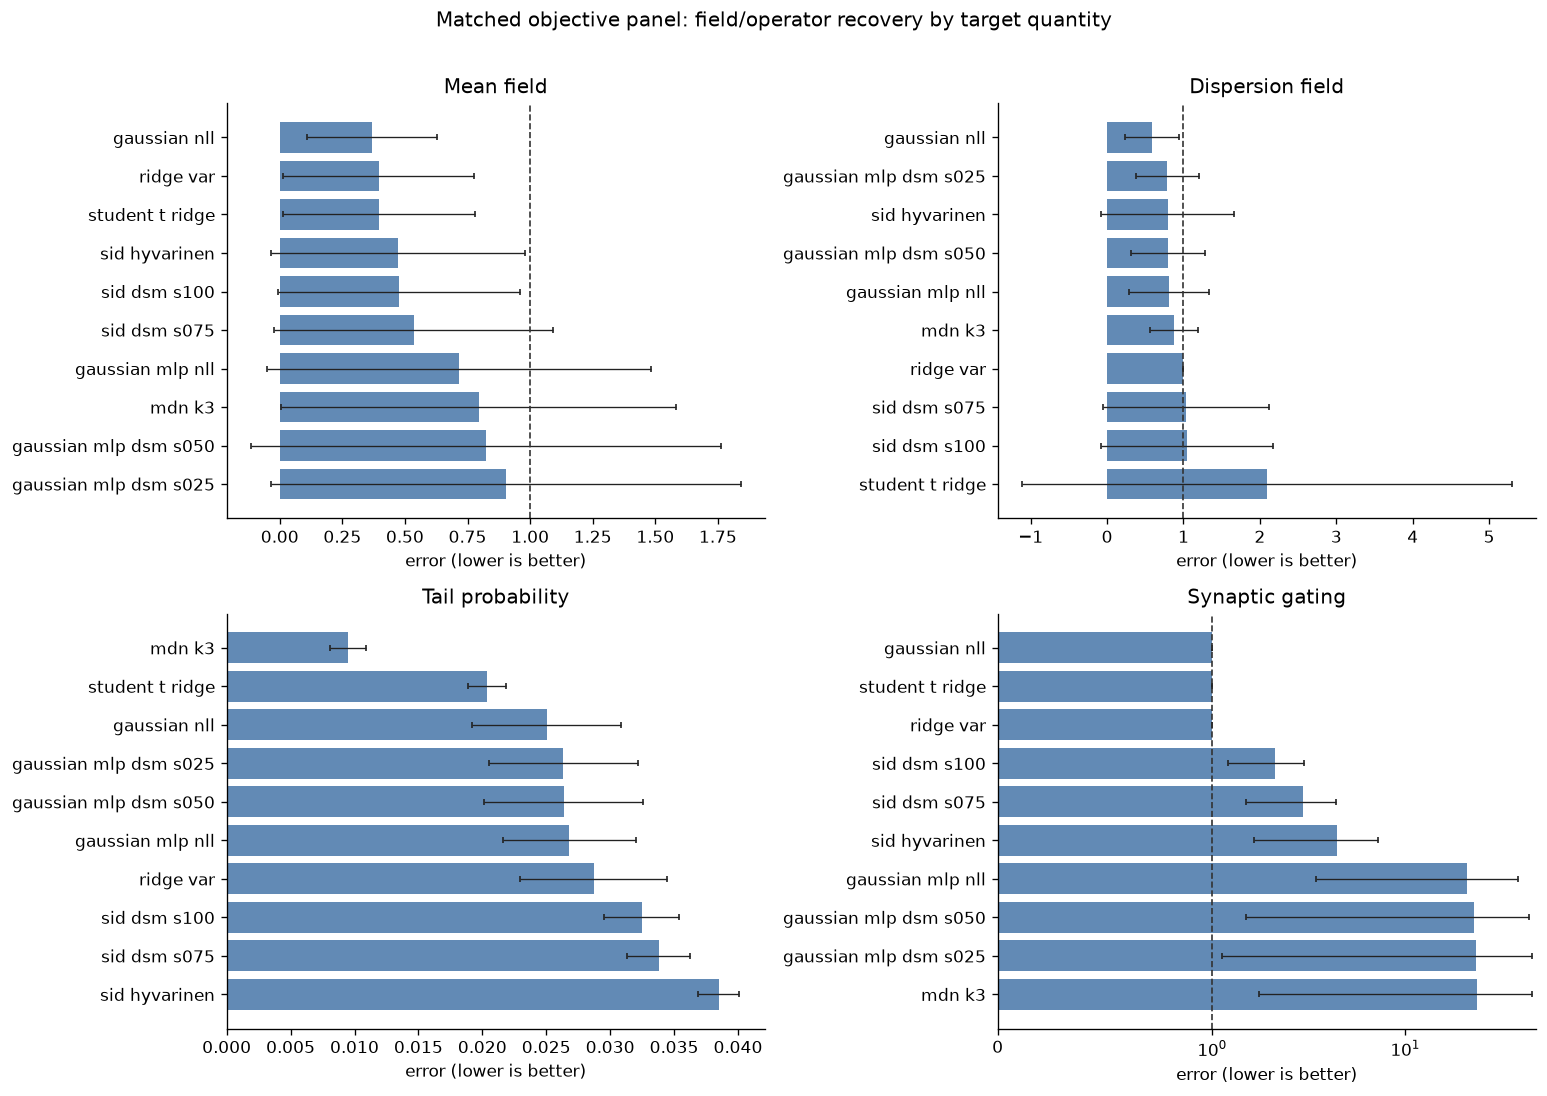

In [3]:
panels=[("Mean field","neuromodulator.physical_mean_state_field.nise","additive_mean",1.0),("Dispersion field","neuromodulator.physical_logvariance_state_field.nise","stochastic_dispersion",1.0),("Tail probability","operator.tail_exceedance_rmse","matched_tail",None),("Synaptic gating","neuromodulator.total_gated_response_state_field.nise","synaptic_gain",1.0)]
fig,axes=plt.subplots(2,2,figsize=(13,9))
for ax,(title,metric,scenario,baseline) in zip(axes.flat,panels):
 s=objective[(objective.metric_id==metric)&(objective.scenario==scenario)].sort_values("mean").head(10); y=np.arange(len(s))
 err=np.maximum(np.vstack([s["mean"]-s["ci95_low"],s["ci95_high"]-s["mean"]]),0)
 ax.barh(y,s["mean"],color="#4776a8",alpha=.85);ax.errorbar(s["mean"],y,xerr=err,fmt="none",ecolor="#222",capsize=2,lw=.8)
 ax.set_yticks(y,s.method.str.replace("_"," "));ax.invert_yaxis();ax.set_title(title);ax.set_xlabel("error (lower is better)")
 if baseline is not None: ax.axvline(baseline,color="#333",ls="--",lw=1)
 if title=="Synaptic gating": ax.set_xscale("symlog",linthresh=1)
fig.suptitle("Matched objective panel: field/operator recovery by target quantity",y=1.01);fig.tight_layout();fig.savefig(OUT/"objective_parity.png",bbox_inches="tight");plt.show()

In [4]:
key_metrics={"mean_field_nise":("neuromodulator.physical_mean_state_field.nise","additive_mean"),"dispersion_field_nise":("neuromodulator.physical_logvariance_state_field.nise","stochastic_dispersion"),"tail_operator_rmse":("operator.tail_exceedance_rmse","matched_tail"),"gating_field_nise":("neuromodulator.total_gated_response_state_field.nise","synaptic_gain"),"matched_tail_nll":("predictive.nll","matched_tail")}
rows=[]
for label,(metric,scenario) in key_metrics.items():
 for _,r in objective[(objective.metric_id==metric)&(objective.scenario==scenario)].sort_values("mean").iterrows(): rows.append([label,r.method,r["mean"],r.ci95_low,r.ci95_high,int(r["count"])])
objective_key=pd.DataFrame(rows,columns=["quantity","method","mean","ci95_low","ci95_high","n_seeds"]);objective_key.to_csv(OUT/"objective_key_results.csv",index=False);objective_key.groupby("quantity").head(4)

,quantity,method,mean,ci95_low,ci95_high,n_seeds
0,mean_field_nise,gaussian_nll,0.368686,0.108547,0.628824,5
1,mean_field_nise,ridge_var,0.394774,0.013676,0.775873,5
2,mean_field_nise,student_t_ridge,0.395383,0.012952,0.777814,5
3,mean_field_nise,sid_hyvarinen,0.472862,-0.035126,0.980850,5
10,dispersion_field_nise,gaussian_nll,0.586382,0.229160,0.943603,5
11,dispersion_field_nise,gaussian_mlp_dsm_s025,0.788671,0.375879,1.201464,5
12,dispersion_field_nise,sid_hyvarinen,0.791491,-0.073265,1.656247,5
13,dispersion_field_nise,gaussian_mlp_dsm_s050,0.794498,0.310986,1.278010,5
20,tail_operator_rmse,mdn_k3,0.009479,0.008091,0.010867,5
21,tail_operator_rmse,student_t_ridge,0.020378,0.018900,0.021855,5


**Interpretation.** Penalized Gaussian likelihood is strongest for physical mean and dispersion fields. Neural DSM slightly improves over neural NLL for dispersion but does not beat the simple Gaussian NLL fit. MDN likelihood is decisively best for matched-tail prediction. No method recovers the mixed derivative defining synaptic gating; zero-emitting baselines score 1 and learned derivative fields are worse.

### Ten-seed finite contrasts: location and low-rank interaction are learnable; covariance and skew are not

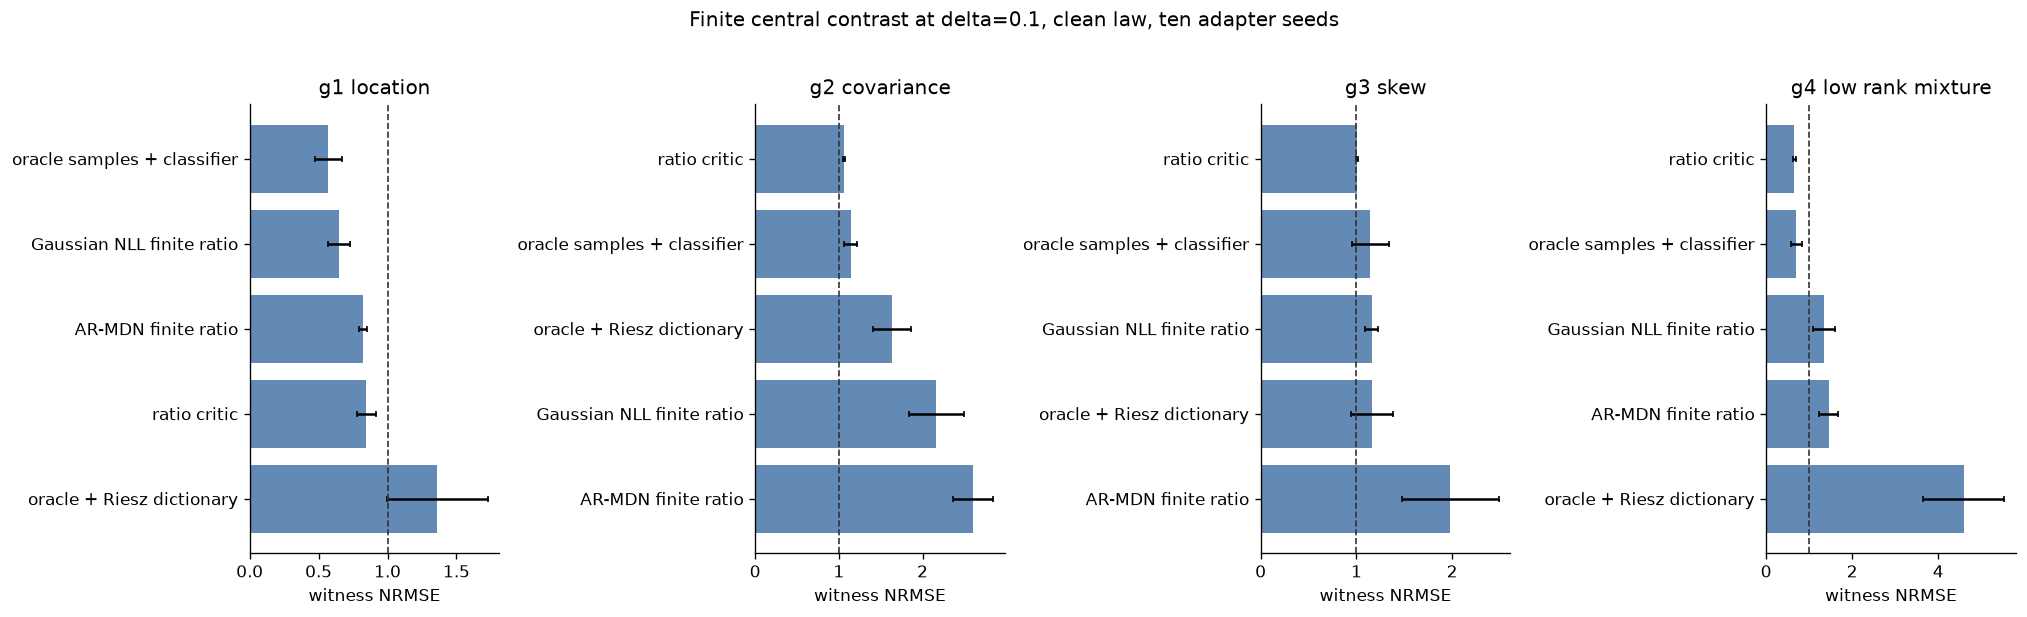

In [5]:
sel=finite[(finite.metric_id=="witness_nrmse")&(finite.delta==0.1)&(finite.law=="clean")].copy()
route_map={("oracle_predictive_law","signed_classifier"):"oracle samples + classifier",("m1_gaussian","central_model_log_ratio"):"Gaussian NLL finite ratio",("m2_ar_vector","central_model_log_ratio"):"AR-MDN finite ratio",("m2_ar_scalar","central_model_log_ratio"):"AR-MDN finite ratio",("m4_ratio","central_model_log_ratio"):"ratio critic",("oracle_predictive_law","signed_riesz_dictionary"):"oracle + Riesz dictionary"}
sel["route"]=[route_map.get((m,k)) for m,k in zip(sel.model_name,sel.method)];sel=sel[sel.route.notna()]
agg=sel.groupby(["generator_id","route"]).value.agg(["mean","std","count"]).reset_index();order=["g1_location","g2_covariance","g3_skew","g4_low_rank_mixture"]
fig,axes=plt.subplots(1,4,figsize=(17,5),sharey=False)
for ax,g in zip(axes,order):
 s=agg[agg.generator_id==g].sort_values("mean");y=np.arange(len(s));ax.barh(y,s["mean"],xerr=s["std"],color="#4776a8",alpha=.85,capsize=2);ax.set_yticks(y,s.route);ax.invert_yaxis();ax.axvline(1,color="#333",ls="--",lw=1);ax.set_title(g.replace("_"," "));ax.set_xlabel("witness NRMSE")
fig.suptitle("Finite central contrast at delta=0.1, clean law, ten adapter seeds",y=1.02);fig.tight_layout();fig.savefig(OUT/"finite_contrast_ten_seed.png",bbox_inches="tight");plt.show();agg.to_csv(OUT/"finite_contrast_ten_seed.csv",index=False)

The oracle infinitesimal tangent itself has negligible finite-target error at delta 0.1, so covariance/skew failure is not Taylor truncation. The oracle-sample classifier is also near or worse than the zero-witness NRMSE of 1 for those DGPs, locating the bottleneck in the adapter/feature geometry rather than the predictive model.

### Classical graph recovery degrades under hidden confounding

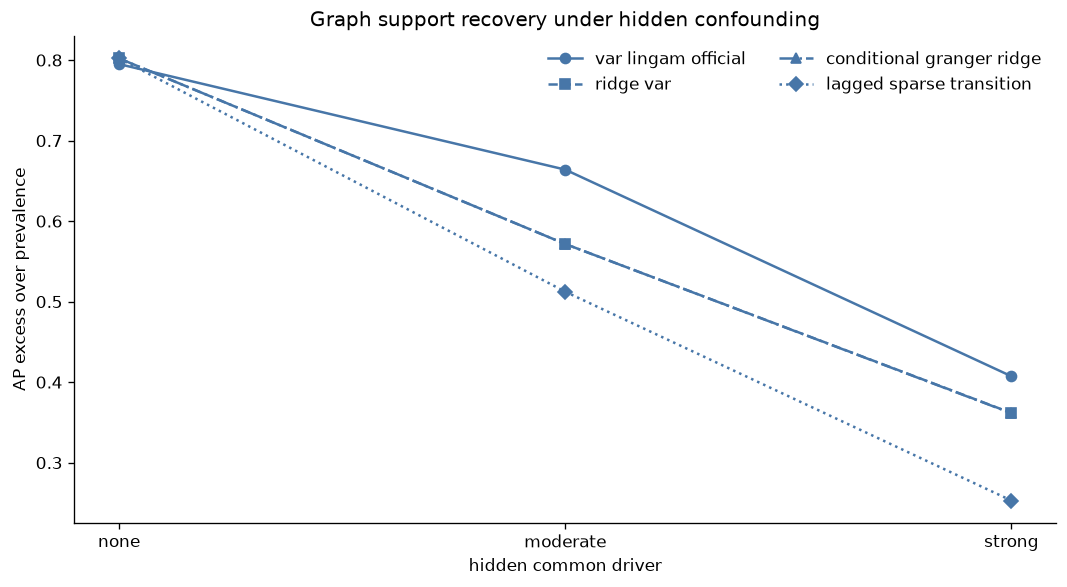

In [6]:
mid="effect.linear_transition_coefficient_vs_mean.auprc_lift_over_prevalence"
graph=causal[causal.metric_id==mid].copy()
scenario_order=["causally_sufficient","moderate_hidden_common_driver","strong_hidden_common_driver"]
methods=["var_lingam_official","ridge_var","conditional_granger_ridge","lagged_sparse_transition"]
styles=[("-","o"),("--","s"),("-.","^") ,(":","D")]
fig,ax=plt.subplots(figsize=(9,5))
for method,(line,marker) in zip(methods,styles):
 s=graph[graph.method==method].set_index("scenario").reindex(scenario_order)
 ax.plot(range(3),s["mean"],marker=marker,linestyle=line,color="#4776a8",label=method.replace("_"," "))
ax.set_xticks(range(3),["none","moderate","strong"]);ax.set_xlabel("hidden common driver");ax.set_ylabel("AP excess over prevalence");ax.set_title("Graph support recovery under hidden confounding");ax.legend(frameon=False,ncol=2);fig.tight_layout();fig.savefig(OUT/"graph_hidden_confounding.png",bbox_inches="tight");plt.show();graph.to_csv(OUT/"graph_hidden_confounding.csv",index=False)

Under causal sufficiency the linear methods recover support strongly (~0.80 AP excess), but every method degrades as the omitted driver strengthens. VAR-LiNGAM is best in the strongest-confounding stratum (~0.41), yet this remains observational support recovery, not causal identification.

### Changepoint detection works only when channel specificity is checked

In [7]:
cp=pd.DataFrame(changepoint["detection_summary"]);cp_key=cp[((cp.scenario=="mean")&(cp.method=="mean_cusum"))|((cp.scenario=="dispersion")&(cp.method=="variance_reliability"))|((cp.scenario=="matched_tail")&(cp.method=="residual_tail_shape"))|(cp.scenario=="null")].copy();cp_key[["scenario","method","call_rate","hit_rate","detected_within_rate","false_positive_rate","mean_absolute_localization_error"]].sort_values(["scenario","method"])

,scenario,method,call_rate,hit_rate,detected_within_rate,false_positive_rate,mean_absolute_localization_error
5,dispersion,variance_reliability,1.00,0.41,0.41,NaN,46.76
10,matched_tail,residual_tail_shape,1.00,1.00,1.00,NaN,1.84
14,mean,mean_cusum,1.00,1.00,1.00,NaN,0.00
18,null,conditional_rule_chow,0.04,NaN,NaN,0.04,NaN
19,null,energy_distance,0.11,NaN,NaN,0.11,NaN
20,null,mean_cusum,0.02,NaN,NaN,0.02,NaN
21,null,mmd_rbf,0.09,NaN,NaN,0.09,NaN
22,null,residual_tail_shape,0.03,NaN,NaN,0.03,NaN
23,null,variance_reliability,0.04,NaN,NaN,0.04,NaN


Matched mean and tail probes detect/localize 100% of their designed changes. The dispersion probe calls all dispersion cases but localizes only 41%. It also calls 95% of mean changes and 99% of matched-tail changes while localizing those nuisance changes poorly. It is a broad residual-instability alarm, not yet a channel-specific dispersion detector.

## Takeaways

1. **Best conditional-law learner:** normalized likelihood. Use MDNs for multimodal/tail laws; Student-t for cheap robust tails; Gaussian likelihood when the law is close to Gaussian.
2. **Best physical mean/dispersion field learner:** simple penalized Gaussian NLL. Hyvarinen/DSM are viable matched-parametric alternatives, but do not beat likelihood here.
3. **Best use of denoising:** numerical stabilization and corrupted-score estimation, not automatic clean-mechanism recovery.
4. **Best finite interaction route:** ratio critic on the low-rank mixture; direct signed classification is competitive for location shifts. Neither solves covariance/skew with the current adapter.
5. **SBTG's role:** reduced-form localization from a joint score. It has moderate mean-like localization but weak, non-specific variance localization and no M2 recovery.
6. **Classical baselines remain hard to beat:** ridge/SINDy dominate mean dynamics and VAR-LiNGAM is strongest under hidden-confounding graph stress.
7. **No current winner for synaptic gating, physical tail-shape derivatives, or robust latent C1 recovery.** These require a different represented operation/target, not a larger sweep of the same objectives.